# Phase 7 — Core Forecasting Models (Use Case 1)

**เป้าหมาย:** สร้างและเทียบโมเดลพยากรณ์ 4 แบบ เพื่อหาว่าแบบไหนเหมาะกับข้อมูล panel นี้ที่สุด:

1. **สถิติคลาสสิก (ETS / Holt-Winters)** — เทรนแยกทีละ series (เฉพาะ top-5 series ที่ขายดีสุด เพราะเทรนทีละ series ทั้ง 270 series ไม่คุ้มเวลา)
2. **Local per-SKU LightGBM** — เทรนแยกโมเดลต่อ 1 SKU (รวมทุก channel/region ของ SKU นั้น) — 30 โมเดล
3. **Global pooled LightGBM** — เทรนโมเดลเดียวจากทุก SKU/channel/region พร้อมกัน
4. **Global pooled XGBoost** — เหมือนข้อ 3 ในแง่ข้อมูล, feature set, global pooling และ walk-forward folds แต่ใช้ configuration ของ XGBoost ที่กำหนดไว้ในโปรเจกต์ เพื่อเป็น challenger model สำหรับ robustness comparison กับ LightGBM

ทุกโมเดลประเมินด้วย **walk-forward CV folds ชุดเดียวกับ Phase 6** เพื่อเทียบกับ baseline ได้ตรงไปตรงมา

In [1]:
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from splits.walk_forward import WalkForwardSplitter
from models.forecast import prepare_categoricals, fit_predict_lgb, fit_predict_xgb, fit_predict_local_per_sku, fit_lgb, ALL_FEATURE_COLS
from models.metrics import score_all

pd.set_option('display.width', 160)

df = pd.read_csv('../data/processed/weekly_features.csv', parse_dates=['week'])
dfc = prepare_categoricals(df)

splitter = WalkForwardSplitter(initial_train_end='2023-09-30', val_fold_weeks=8, final_test_weeks=10)
folds, final_test_weeks = splitter.get_folds(dfc)
print(f'{len(folds)} CV folds, final holdout = {len(final_test_weeks)} weeks (untouched until Phase 13)')

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\acer\\.matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


7 CV folds, final holdout = 10 weeks (untouched until Phase 13)


## 1. Global Pooled LightGBM

โมเดลเดียวเทรนจากข้อมูลทุก SKU × channel × region พร้อมกัน ใช้ทุกฟีเจอร์ที่มี (`ALL_FEATURE_COLS` ใน `src/models/forecast.py`) — categorical features (`sku`, `channel`, `region`, `category`, `segment`, `brand`, `lifecycle_stage`) ใช้ LightGBM's native categorical handling ไม่ต้อง one-hot encode


In [2]:
fold_scores_global = []
for f in folds:
    train = dfc[dfc.week.isin(f.train_weeks)]
    val = dfc[dfc.week.isin(f.val_weeks)]
    pred = fit_predict_lgb(train, val)
    fold_scores_global.append(score_all(val.target_next_week.values, pred))

global_cv = {k: np.mean([s[k] for s in fold_scores_global]) for k in fold_scores_global[0]}
print('Global pooled LightGBM, CV average:')
print({k: round(v, 3) for k, v in global_cv.items()})


Global pooled LightGBM, CV average:
{'MAE': np.float64(25.169), 'RMSE': np.float64(32.263), 'WAPE': np.float64(0.224), 'SMAPE': np.float64(0.228)}


## 2. Global Pooled XGBoost

โมเดลเดียวกับข้อ 1 ในแง่ data/feature (pooled ข้าม SKU × channel × region, ใช้ฟีเจอร์ครบชุดเดียวกัน, categorical column ใช้ native categorical support เหมือนกัน — ไม่ one-hot) รวมถึงใช้ walk-forward validation folds ชุดเดียวกัน แต่ใช้ configuration ของ XGBoost ตามที่กำหนดไว้ในโปรเจกต์ — ตั้งใจใช้เป็น challenger model สำหรับ robustness comparison กับ Global pooled LightGBM เพื่อดูว่าผลลัพธ์ยังใกล้เคียงกันหรือไม่เมื่อเปลี่ยน boosting implementation โดยไม่ได้สมมติว่า configuration ของทั้งสองโมเดลเหมือนกันทุกด้าน

In [3]:
fold_scores_global_xgb = []
for f in folds:
    train = dfc[dfc.week.isin(f.train_weeks)]
    val = dfc[dfc.week.isin(f.val_weeks)]
    pred = fit_predict_xgb(train, val)
    fold_scores_global_xgb.append(score_all(val.target_next_week.values, pred))

global_xgb_cv = {k: np.mean([s[k] for s in fold_scores_global_xgb]) for k in fold_scores_global_xgb[0]}
print('Global pooled XGBoost, CV average:')
print({k: round(v, 3) for k, v in global_xgb_cv.items()})

Global pooled XGBoost, CV average:
{'MAE': np.float64(25.315), 'RMSE': np.float64(32.49), 'WAPE': np.float64(0.225), 'SMAPE': np.float64(0.229)}


### เปรียบเทียบ WAPE ราย Walk-forward Fold

ตารางต่อไปใช้ผลที่คำนวณไว้แล้วใน `fold_scores_global` และ `fold_scores_global_xgb` เพื่อดูว่าความใกล้เคียงของ WAPE เกิดสม่ำเสมอเพียงใดในทั้ง 7 folds โดยไม่ retrain หรือเปลี่ยน configuration ของโมเดล

In [4]:
fold_wape_comparison = pd.DataFrame({
    'fold': np.arange(1, len(fold_scores_global) + 1),
    'LightGBM_WAPE': [score['WAPE'] for score in fold_scores_global],
    'XGBoost_WAPE': [score['WAPE'] for score in fold_scores_global_xgb],
})
fold_wape_comparison['difference'] = (
    fold_wape_comparison['XGBoost_WAPE'] - fold_wape_comparison['LightGBM_WAPE']
)

fold_wape_summary = pd.DataFrame({
    'model': ['Global pooled LightGBM', 'Global pooled XGBoost'],
    'mean_WAPE': [fold_wape_comparison['LightGBM_WAPE'].mean(), fold_wape_comparison['XGBoost_WAPE'].mean()],
    'std_WAPE': [fold_wape_comparison['LightGBM_WAPE'].std(ddof=1), fold_wape_comparison['XGBoost_WAPE'].std(ddof=1)],
})

display(fold_wape_comparison.round(4))
display(fold_wape_summary.round(4))

,fold,LightGBM_WAPE,XGBoost_WAPE,difference
0,1,0.2316,0.2377,0.0061
1,2,0.2319,0.2338,0.0019
2,3,0.2194,0.2200,0.0006
3,4,0.2242,0.2247,0.0005
4,5,0.2200,0.2195,-0.0006
5,6,0.2172,0.2186,0.0014
6,7,0.2203,0.2201,-0.0002


,model,mean_WAPE,std_WAPE
0,Global pooled LightGBM,0.2235,0.0060
1,Global pooled XGBoost,0.2249,0.0077


**ผลลัพธ์:** ภายใต้ configuration ที่ใช้ในการทดลองนี้ Global pooled LightGBM และ Global pooled XGBoost ให้ WAPE เฉลี่ยใกล้เคียงกันมาก และตารางราย fold แสดงขนาดกับทิศทางของความแตกต่างในแต่ละช่วงเวลาโดยตรง ขณะที่ความแตกต่างระหว่าง Global pooled และ Local per-SKU LightGBM มีขนาดชัดเจนกว่า ผลนี้จึงบ่งชี้ว่า pooling strategy มีผลต่อ performance มากกว่าความแตกต่างระหว่าง boosting implementations สำหรับการทดลองชุดนี้ โดยไม่ได้อ้างนัยสำคัญทางสถิติหรือสรุปเป็นกฎทั่วไป

## 3. Local Per-SKU LightGBM

เทรนแยกโมเดลต่อ SKU (30 โมเดล, รวม channel/region ของ SKU นั้นเป็น training data เดียว) — ทดสอบสมมติฐานว่าการ pool ข้อมูลข้าม SKU (global model) ช่วยจริงหรือไม่ เทียบกับการให้แต่ละ SKU มีโมเดลเฉพาะตัว

In [5]:
fold_scores_local = []
for f in folds:
    train = dfc[dfc.week.isin(f.train_weeks)]
    val = dfc[dfc.week.isin(f.val_weeks)]
    pred = fit_predict_local_per_sku(train, val)
    mask = ~np.isnan(pred)
    fold_scores_local.append(score_all(val.target_next_week.values[mask], pred[mask]))

local_cv = {k: np.mean([s[k] for s in fold_scores_local]) for k in fold_scores_local[0]}
print('Local per-SKU LightGBM, CV average:')
print({k: round(v, 3) for k, v in local_cv.items()})


Local per-SKU LightGBM, CV average:
{'MAE': np.float64(28.824), 'RMSE': np.float64(36.845), 'WAPE': np.float64(0.257), 'SMAPE': np.float64(0.257)}


**ผลลัพธ์:** Global pooled LightGBM (WAPE ต่ำกว่า) ชนะ local per-SKU LightGBM — ยืนยันสมมติฐานว่าการแบ่งปันข้อมูลข้าม SKU ช่วยได้จริง โดยเฉพาะกับ SKU ที่มีประวัติสั้นหรือขายไม่บ่อย ซึ่งโมเดลแยกต่อ SKU มีข้อมูลไม่พอเรียนรู้ pattern ที่ดี (การทดลองนี้เทียบเฉพาะ pooling axis ด้วย LightGBM ตัวเดียว — ดูข้อ 2 ด้านบนสำหรับ library axis)

## 4. Top-5 Series Controlled Comparison: ETS vs Global LightGBM

เทรน SARIMA/ETS แยกทีละ series ทั้ง 270 series ไม่คุ้มเวลาและข้อมูลบาง series สั้นเกินไปสำหรับ seasonal ETS (ต้องการอย่างน้อย ~2 รอบฤดูกาล) จึงเลือกทำเฉพาะ **5 series ที่ขายรวมสูงสุด** เป็นตัวแทน แล้วเทียบกับ Global LightGBM **บน series ชุดเดียวกันเท่านั้น** เพื่อให้เทียบกันแบบยุติธรรม (ไม่ใช่เทียบ WAPE ข้าม scope ที่ต่างกัน)

In [6]:
top_series = df.groupby(['sku', 'channel', 'region']).units_sold.sum().sort_values(ascending=False).head(5)
print('Top-5 series by total units_sold:')
print(top_series)


Top-5 series by total units_sold:
sku     channel   region  
YO-029  Retail    PL-South    19861
                  PL-North    19819
YO-005  Retail    PL-North    19543
        Discount  PL-North    19537
                  PL-South    19514
Name: units_sold, dtype: int64


In [7]:
ets_scores = []
lgb_on_top5_scores = []

for f in folds:
    train = dfc[dfc.week.isin(f.train_weeks)]
    val_all = dfc[dfc.week.isin(f.val_weeks)]
    pred_all = fit_predict_lgb(train, val_all)
    val_all = val_all.assign(pred=pred_all)
    for (sku, ch, rg) in top_series.index:
        sub = val_all[(val_all.sku == sku) & (val_all.channel == ch) & (val_all.region == rg)]
        if len(sub):
            lgb_on_top5_scores.append(score_all(sub.target_next_week.values, sub.pred.values))

for (sku, ch, rg) in top_series.index:
    series_df = df[(df.sku == sku) & (df.channel == ch) & (df.region == rg)].sort_values('week').set_index('week')
    series_df.index = pd.DatetimeIndex(series_df.index)
    for f in folds:
        train_s = series_df[series_df.index.isin(f.train_weeks)]['units_sold'].asfreq('W-MON')
        val_s = series_df[series_df.index.isin(f.val_weeks)]
        if len(train_s) < 30 or len(val_s) == 0:
            continue
        try:
            model = ExponentialSmoothing(
                train_s, trend='add', seasonal='add', seasonal_periods=52, initialization_method='estimated'
            ).fit()
            fc = model.forecast(len(val_s))
            fc.index = val_s.index
        except Exception:
            continue
        actual = val_s['target_next_week'].values
        pred = fc.values
        mask = ~np.isnan(actual)
        if mask.sum() == 0:
            continue
        ets_scores.append(score_all(actual[mask], pred[mask]))

ets_cv = {k: np.mean([s[k] for s in ets_scores]) for k in ets_scores[0]}
lgb_top5_cv = {k: np.mean([s[k] for s in lgb_on_top5_scores]) for k in lgb_on_top5_scores[0]}
print('ETS (Holt-Winters), top-5 series, CV average:')
print({k: round(v, 3) for k, v in ets_cv.items()})
print('Global LightGBM, SAME top-5 series, CV average:')
print({k: round(v, 3) for k, v in lgb_top5_cv.items()})

top5_controlled_comparison = pd.DataFrame([
    {'model': 'ETS (Holt-Winters)', **ets_cv},
    {'model': 'Global LightGBM (same top-5 series)', **lgb_top5_cv},
]).sort_values('WAPE').reset_index(drop=True)
top5_controlled_comparison.round(3)


ETS (Holt-Winters), top-5 series, CV average:
{'MAE': np.float64(39.13), 'RMSE': np.float64(47.438), 'WAPE': np.float64(0.301), 'SMAPE': np.float64(0.292)}
Global LightGBM, SAME top-5 series, CV average:
{'MAE': np.float64(28.444), 'RMSE': np.float64(35.022), 'WAPE': np.float64(0.214), 'SMAPE': np.float64(0.216)}


,model,MAE,RMSE,WAPE,SMAPE
0,Global LightGBM (same top-5 series),28.444,35.022,0.214,0.216
1,ETS (Holt-Winters),39.130,47.438,0.301,0.292


**ผลลัพธ์:** แม้เทียบเฉพาะ 5 series ที่มีข้อมูลยาวและสม่ำเสมอที่สุด (เหมาะกับ ETS ที่สุดแล้ว) LightGBM ก็ยังชนะ ETS — เพราะ ETS ใช้แค่ประวัติของ series ตัวเองในการพยากรณ์ ในขณะที่ LightGBM ใช้ทั้งประวัติของ series นั้น **และ** ข้อมูลบริบท (ราคา โปรโมชัน ฤดูกาล enrichment) ที่ ETS ไม่รองรับ

ETS ถูกแยกไว้ใน controlled comparison นี้และไม่รวมใน full-panel leaderboard ด้านล่าง เพราะ metric ของ ETS คำนวณจาก top-5 series ซึ่งเป็น evaluation population คนละชุดกับโมเดลใน full-panel comparison การนำมาจัดอันดับร่วมกันจึงไม่ใช่การเปรียบเทียบแบบ apples-to-apples

## 5. Full-panel Leaderboard (รวม Baseline จาก Phase 6)

ตารางนี้รวมเฉพาะโมเดลที่ประเมินใน full-panel CV scope เดียวกัน ส่วน ETS แสดงแยกไว้ใน Top-5 Series Controlled Comparison ด้านบน

In [8]:
from models.baseline import add_baseline_predictions

dfb = add_baseline_predictions(df)
baseline_rows = []
for name, col in [('Naive', 'pred_naive'), ('Seasonal Naive', 'pred_seasonal_naive'), ('Moving Avg (4w)', 'pred_moving_avg_4')]:
    fold_scores = []
    for f in folds:
        val = dfb[dfb.week.isin(f.val_weeks)].dropna(subset=[col, 'target_next_week'])
        if len(val) == 0:
            continue
        fold_scores.append(score_all(val.target_next_week.values, val[col].values))
    baseline_rows.append({'model': name, **{k: np.mean([s[k] for s in fold_scores]) for k in fold_scores[0]}})

comparison = pd.DataFrame(baseline_rows + [
    {'model': 'Local per-SKU LightGBM', **local_cv},
    {'model': 'Global pooled LightGBM', **global_cv},
    {'model': 'Global pooled XGBoost', **global_xgb_cv},
])
comparison = comparison.sort_values('WAPE').reset_index(drop=True)
comparison.round(3)

,model,MAE,RMSE,WAPE,SMAPE
0,Global pooled LightGBM,25.169,32.263,0.224,0.228
1,Global pooled XGBoost,25.315,32.490,0.225,0.229
2,Moving Avg (4w),27.348,35.134,0.243,0.246
3,Local per-SKU LightGBM,28.824,36.845,0.257,0.257
4,Naive,34.225,43.847,0.304,0.307
5,Seasonal Naive,39.935,51.328,0.356,0.338


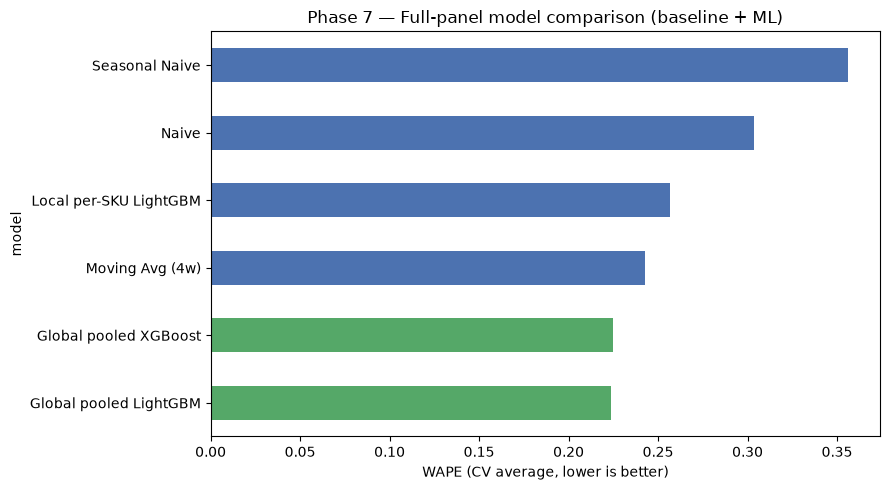

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = comparison.set_index('model')['WAPE'].sort_values()
colors = ['#55A868' if m in ('Global pooled LightGBM', 'Global pooled XGBoost') else '#4C72B0' for m in plot_df.index]
plot_df.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('WAPE (CV average, lower is better)')
ax.set_title('Phase 7 — Full-panel model comparison (baseline + ML)')
plt.tight_layout()
plt.savefig('../reports/figures/phase7_model_comparison.png', dpi=120)
plt.show()

**สรุป:** ใน full-panel scope เดียวกัน Global pooled LightGBM และ Global pooled XGBoost มี WAPE ใกล้เคียงกันมาก ขณะที่ความแตกต่างระหว่าง Global pooled และ Local per-SKU LightGBM มีขนาดชัดเจนกว่า ภายใต้ configuration ของการทดลองนี้จึงบ่งชี้ว่า pooling strategy มีผลต่อ performance มากกว่าความแตกต่างระหว่าง boosting implementations โดยยังคงเลือก **Global pooled LightGBM** เป็นโมเดลหลักของโปรเจกต์ เพราะ supporting metrics ใน run ปัจจุบันต่ำกว่าเล็กน้อยและ downstream phases ใช้โมเดลนี้ต่ออยู่แล้ว ส่วน XGBoost ทำหน้าที่เป็น challenger model สำหรับ robustness comparison

## 6. Feature Importance ของ Global Model

เทรนโมเดล global บนข้อมูลทั้งหมดก่อนช่วง final holdout (คือ CV ทั้งหมดรวมกัน) เพื่อดู feature importance โดยรวม — ช่วยให้เห็นภาพคร่าวๆ ก่อนวัดผลอย่างเป็นทางการใน Phase 11 (feature ablation) (ใช้ global LightGBM เป็นตัวแทน เพราะเป็นโมเดลที่ carry ต่อไปยัง phase ถัดไป)

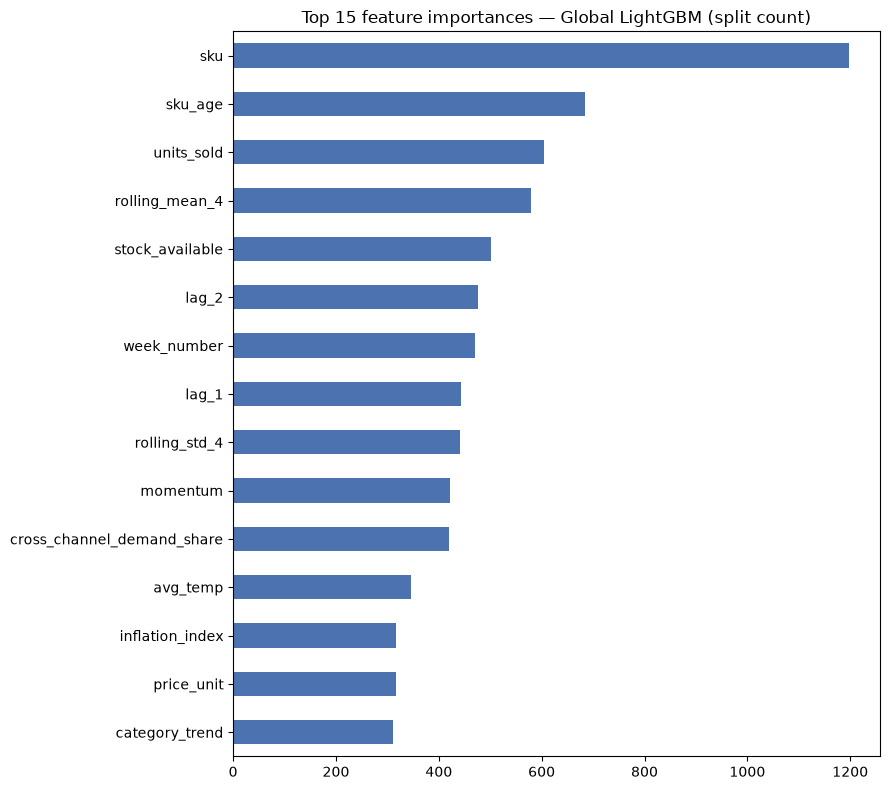

In [10]:
cv_all = dfc[~dfc.week.isin(final_test_weeks)]
full_model = fit_lgb(cv_all)

importance = pd.Series(full_model.feature_importances_, index=ALL_FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 8))
importance.head(15).sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title('Top 15 feature importances — Global LightGBM (split count)')
plt.tight_layout()
plt.savefig('../reports/figures/phase7_feature_importance.png', dpi=120)
plt.show()


## 7. สรุป Phase 7

**Full-panel comparison:** leaderboard ที่คำนวณจากโค้ดด้านบนเปรียบเทียบ Global pooled LightGBM, Global pooled XGBoost, Local per-SKU LightGBM, Moving Avg (4w), Naive และ Seasonal Naive บน CV scope เดียวกัน ผลของ Global pooled LightGBM และ Global pooled XGBoost ใกล้เคียงกันมาก ขณะที่ความแตกต่างระหว่าง Global pooled และ Local per-SKU LightGBM มีขนาดชัดเจนกว่า ภายใต้ configuration ที่ใช้ในการทดลองนี้ ผลจึงบ่งชี้ว่า pooling strategy มีผลต่อ performance มากกว่าความแตกต่างระหว่าง boosting implementations โดยไม่อ้างว่าเป็นข้อสรุปสากลหรือมีนัยสำคัญทางสถิติ

**Top-5 Series Controlled Comparison:** ETS / Holt-Winters และ Global LightGBM ถูกเปรียบเทียบบน top-5 series ชุดเดียวกันในตารางแยกต่างหาก ETS ไม่อยู่ใน full-panel leaderboard เพราะ evaluation population ต่างกัน

**โมเดลที่เลือกใช้ต่อในโปรเจกต์: Global pooled LightGBM** — WAPE ใกล้เคียงกับ Global pooled XGBoost มาก แต่ LightGBM ต่ำกว่าเล็กน้อยใน supporting metrics ของ run ปัจจุบัน และเป็นโมเดลที่ downstream project phases ใช้ต่ออยู่แล้ว ส่วน Global pooled XGBoost เป็น challenger model สำหรับ robustness comparison ไม่ใช่ upper bound หรือเพดานอ้างอิง